# 贝叶斯推断与后验预测

学习目标：从小型概率模型推导后验，计算点估计、可信区间和后验预测，比较先验及数据量对结果的影响。

前置知识：条件概率、贝叶斯公式、似然、期望与方差、定积分、Python 数组与函数。

运行环境：Python 3.12；使用 NumPy、SciPy 与 Matplotlib，具体版本见环境说明。

环境准备：[环境配置与运行](README.md)。

工作目录：本 Notebook 所在目录；重启内核后从上到下运行。

本章的二元记录均为教学构造或明确标记的模拟。所有概率与参数均无量纲，成功次数以“次”计；不读取外部数据。

## 1 一次成功怎样改变判断

设一个装置的成功概率为 $\theta$，只考虑 $\theta=1/4$ 和 $\theta=3/4$ 两种可能。观察前各给一半概率。装置选定后参数保持不变，每次结果 $X$ 取 1 表示成功、0 表示失败，满足 $P(X=1\mid\theta)=\theta$。

现在观察到 $D=(1)$。两种参数与这条记录同时出现的概率分别为 $\tfrac12\times\tfrac14=\tfrac18$、$\tfrac12\times\tfrac34=\tfrac38$；总概率为 $1/2$。各自除以总概率，得到 $P(\theta=1/4\mid D)=1/4$、$P(\theta=3/4\mid D)=3/4$。

这里更新的是对未知参数的概率描述，没有把装置的参数改成新数值。下面用分数直接核对手算。

In [1]:
from fractions import Fraction

theta_small = [Fraction(1, 4), Fraction(3, 4)]
prior_small = [Fraction(1, 2), Fraction(1, 2)]
joint_small = [p * t for p, t in zip(prior_small, theta_small)]
evidence_small = sum(joint_small)
posterior_small = [value / evidence_small for value in joint_small]

print("记录的总概率：", evidence_small)  # 1/2。
print("两个参数的后验：", posterior_small)  # 1/4、3/4。
print("后验概率之和：", sum(posterior_small))  # 1。

记录的总概率： 1/2
两个参数的后验： [Fraction(1, 4), Fraction(3, 4)]
后验概率之和： 1


## 2 先验、似然与归一化

一般地，离散参数有 $J$ 个候选值 $\theta_j$，$j=1,\ldots,J$。令 $\pi_j=P(\theta=\theta_j)$，满足 $\pi_j\geq0$、$\sum_j\pi_j=1$。记录 $D$ 固定后，贝叶斯公式为

$$
P(\theta=\theta_j\mid D)
=\frac{L_j\pi_j}{Z},\qquad
L_j=P(D\mid\theta_j),\quad Z=\sum_{j=1}^{J}L_j\pi_j>0.
$$

| 原文名称 | 中文名称／含义 |
| --- | --- |
| prior | 先验；观察当前数据之前对参数的概率描述 |
| likelihood | 似然；固定数据后，将其条件概率视为参数的函数 |
| evidence | 证据，又称边际似然；本章离散数据记录的总概率 $Z=P(D)$ |
| posterior | 后验；给定当前数据之后对参数的概率描述 |

似然不必对参数求和为 1，不能直接当作参数的概率。归一化作用于“先验 × 似然”的结果。

In [2]:
import numpy as np

theta_values = np.array([0.25, 0.75])
prior = np.array([0.8, 0.2])
likelihood = theta_values.copy()  # 仍然只观察到一次成功。
numerator = prior * likelihood
posterior = numerator / numerator.sum()

print("参数  先验  似然  乘积  后验")
for row in zip(theta_values, prior, likelihood, numerator, posterior):
    print(" ".join(f"{value:.3f}" for value in row))  # 两行后验分别约 0.571、0.429；先验较大的第一个候选仍有较高后验。
# 后验为 [4/7, 3/7]；较大的似然不一定对应较大的后验。
print("后验之和：", posterior.sum())  # 预期为 1。

参数  先验  似然  乘积  后验
0.250 0.800 0.250 0.200 0.571
0.750 0.200 0.750 0.150 0.429
后验之和： 1.0


若某个离散候选值的先验概率为 0，那么在 $Z>0$ 时，它的后验仍为 0。若所有候选值都不能产生观测，$Z=0$，这套模型无法做此次条件更新；不能把全零数组直接除以其和。

这与连续密度在单个点上为 0 的讨论不同。下面仅演示有限候选参数被先验排除的情形。

In [3]:
rigid_prior = np.array([1.0, 0.0])
rigid_numerator = rigid_prior * theta_values**4  # 四次成功仍不能恢复被排除的候选值。
print("刚性先验的后验：", rigid_numerator / rigid_numerator.sum())  # [1. 0.]。

impossible_theta = np.array([0.0])
impossible_evidence = np.sum(np.array([1.0]) * impossible_theta)
print("不可能观测的证据：", impossible_evidence)  # 0；不执行除法。

刚性先验的后验： [1. 0.]
不可能观测的证据： 0.0


## 3 顺序更新与整批更新

设 $D_1,D_2$ 是两批不重叠记录，给定同一个 $\theta$ 后，两批数据条件独立。则

$$
\pi(\theta\mid D_1,D_2)
\propto P(D_2\mid\theta)\pi(\theta\mid D_1)
\propto P(D_2\mid\theta)P(D_1\mid\theta)\pi(\theta).
$$

因此，将第一批后验用作第二批先验，与整批更新等价。对条件独立、同一成功概率的二元记录 $D=(x_1,\ldots,x_n)$，令成功总数 $k=\sum_{i=1}^n x_i$，其有序记录的似然为 $\theta^k(1-\theta)^{n-k}$。

如果记录存在依赖，第二批似然应是 $P(D_2\mid\theta,D_1)$；如果重复输入同一记录，就相当于擅自增加了一次观测。

In [4]:
observed = np.array([1, 1, 0, 1])
initial_prior = np.array([0.5, 0.5])
sequential = initial_prior.copy()
# 每个观测先贡献一个似然因子，再把更新后的两项权重归一化。
for result in observed:
    one_likelihood = theta_values if result == 1 else 1 - theta_values
    sequential *= one_likelihood
    sequential /= sequential.sum()

n = observed.size
k = observed.sum()
batch_numerator = initial_prior * theta_values**k * (1 - theta_values) ** (n - k)
batch = batch_numerator / batch_numerator.sum()
print("顺序后验：", sequential)  # [0.1, 0.9]。
print("整批后验：", batch)  # 预期约为 [0.1 0.9]。
print("最大差值：", np.max(np.abs(sequential - batch)))  # 应接近 0。

顺序后验： [0.1 0.9]
整批后验： [0.1 0.9]
最大差值： 1.3877787807814457e-17


## 4 连续参数用积分归一化

现在允许 $0\leq\theta\leq1$，用密度 $\pi(\theta)$ 描述先验。连续情形的更新是

$$
\pi(\theta\mid D)=\frac{P(D\mid\theta)\pi(\theta)}{Z},\qquad
Z=\int_0^1 P(D\mid t)\pi(t)\,dt>0,
$$

其中 $t$ 只是积分变量。密度值不是该点的概率，区间概率要对密度积分；连续后验中任意单点的概率都是 0。

取均匀先验 $\pi(\theta)=1$，观察有序记录 $(1,0,1)$。其似然为 $\theta^2(1-\theta)$，所以

$$
Z=\int_0^1(\theta^2-\theta^3)\,d\theta=\frac13-\frac14=\frac1{12},\qquad
\pi(\theta\mid D)=12\theta^2(1-\theta).
$$

手算后再用 scipy.integrate.quad 核对积分；返回的第二项是数值积分的绝对误差估计，不是参数估计的不确定性。

In [5]:
from scipy.integrate import quad


def small_posterior_density(theta):
    return 12 * theta**2 * (1 - theta)


normalization, integration_error = quad(small_posterior_density, 0, 1)
upper_half, _ = quad(small_posterior_density, 0.5, 1)
print("后验积分：", normalization)  # 1。
print("积分误差估计：", integration_error)  # 本次数值约为 1.1e-14。
print("参数大于 0.5 的后验概率：", upper_half)  # 11/16 = 0.6875。
print("0.5 处的密度：", small_posterior_density(0.5))  # 1.5，不是概率 1.5。

后验积分： 1.0
积分误差估计： 1.1102230246251565e-14
参数大于 0.5 的后验概率： 0.6875
0.5 处的密度： 1.5


## 5 Beta 先验与二项似然

Beta 分布用两个正实数 $a,b>0$ 控制形状，密度为

$$
\pi(\theta)=\frac{\theta^{a-1}(1-\theta)^{b-1}}{B(a,b)},\quad0<\theta<1,
\qquad B(a,b)=\int_0^1t^{a-1}(1-t)^{b-1}\,dt.
$$

$B(a,b)$ 是使积分为 1 的 Beta 函数。$a,b$ 是先验的参数，用来区别于待推断的成功概率 $\theta$，也称超参数。Beta(1,1) 就是均匀分布；Beta(2,2) 的密度为 $6\theta(1-\theta)$，更集中于中间。

下面将直接按公式计算的密度与 scipy.stats.beta.pdf 对照。这里的 beta 函数与 beta 分布对象用途不同，导入时分别命名。

In [6]:
from scipy.special import beta as beta_function
from scipy.stats import beta, betabinom, binom

a, b = 2.0, 2.0
theta_grid = np.linspace(0.001, 0.999, 501)
prior_pdf = theta_grid ** (a - 1) * (1 - theta_grid) ** (b - 1) / beta_function(a, b)
print("B(2, 2)：", beta_function(a, b))  # 1/6。
# 预期两种密度计算相近；本次最大差约 1.1e-15，处于舍入量级。
print(
    "密度公式与库的最大差值：", np.max(np.abs(prior_pdf - beta.pdf(theta_grid, a, b)))
)
# 在当前小尺度问题中，两种计算的差值应小于 1e-12。

B(2, 2)： 0.16666666666666666
密度公式与库的最大差值： 1.1102230246251565e-15


设给定 $\theta$ 后，$n\geq1$ 次试验相互独立且成功概率相同。只保留成功次数 $K=k$ 时，$k\in\{0,\ldots,n\}$，有二项似然

$$
P(K=k\mid\theta)=\binom nk\theta^k(1-\theta)^{n-k}.
$$

与 Beta 先验相乘后，关于 $\theta$ 的幂次分别相加：

$$
\pi(\theta\mid K=k)\propto
\theta^{a+k-1}(1-\theta)^{b+n-k-1}.
$$

因此，记 $A=a+k$、$B=b+n-k$，后验为 Beta($A,B$)。先验与后验属于同一分布族，称为共轭。对这次计数记录，证据为

$$
Z=P(K=k)=\binom nk\frac{B(A,B)}{B(a,b)}.
$$

组合数与参数无关，计算后验时会约掉；计算计数记录的证据时必须保留。某一条有序记录和“所有含 $k$ 次成功的记录”是不同事件，二者证据不同。

In [7]:
from math import comb

n, k = 8, 6
post_a, post_b = a + k, b + n - k
count_evidence = comb(n, k) * beta_function(post_a, post_b) / beta_function(a, b)
ordered_evidence = beta_function(post_a, post_b) / beta_function(a, b)
posterior_pdf = beta.pdf(theta_grid, post_a, post_b)
normalized_product = binom.pmf(k, n, theta_grid) * prior_pdf / count_evidence

print("后验参数：", post_a, post_b)  # Beta(8, 4)。
print("计数记录的证据：", count_evidence)  # 预期约为 0.127273。
print("计数证据 / 有序记录证据：", count_evidence / ordered_evidence)  # C(8, 6) = 28。
print("后验密度最大差值：", np.max(np.abs(normalized_product - posterior_pdf)))  # 本次数值约为 5.8e-15。
print("后验积分：", quad(lambda t: beta.pdf(t, post_a, post_b), 0, 1)[0])  # 预期约为 1。

后验参数： 8.0 4.0
计数记录的证据： 0.1272727272727273
计数证据 / 有序记录证据： 28.0
后验密度最大差值： 5.773159728050814e-15
后验积分： 0.9999999999999997


Beta 更新也可以逐批相加。只要先验相同、观测没有重复且模型条件一致，成功数和失败数分别累加即可。下面把同一组 8 次试验拆成 3 次和 5 次，不额外加入观测。

In [8]:
first_n, first_k = 3, 2
second_n, second_k = 5, 4
first_a, first_b = a + first_k, b + first_n - first_k
final_a = first_a + second_k
final_b = first_b + second_n - second_k

print("分批更新的参数：", final_a, final_b)  # 同样为 8、4。
# 预期接近 0；本次计算为 0。
print(
    "与整批密度的最大差值：",
    np.max(np.abs(beta.pdf(theta_grid, final_a, final_b) - posterior_pdf)),
)

分批更新的参数： 8.0 4.0
与整批密度的最大差值： 0.0


## 6 后验均值与 MAP

点估计用一个数概括后验，会丢失分布宽度等信息。后验均值是 $\mathbb E[\theta\mid D]$；最大后验估计（maximum a posteriori，MAP）是使后验概率质量或密度最大的参数值。

对 Beta($A,B$)，令 $T=A+B$。利用 Beta 函数积分，

$$
\mathbb E[\theta\mid D]=\frac{B(A+1,B)}{B(A,B)}=\frac A T,\qquad
\mathbb E[\theta^2\mid D]=\frac{A(A+1)}{T(T+1)},
$$

从第二个式子减去均值的平方，得 $\operatorname{Var}(\theta\mid D)=AB/[T^2(T+1)]$。这描述参数后验的离散程度。

若 $A>1,B>1$，对数密度的一阶导数为 $(A-1)/\theta-(B-1)/(1-\theta)$；令其为 0 得

$$\hat\theta_{\mathrm{MAP}}=\frac{A-1}{A+B-2}.$$

此时二阶导数为 $-(A-1)/\theta^2-(B-1)/(1-\theta)^2<0$，所以它是唯一内点最大值。均值与 MAP 一般不同。

In [9]:
total_shape = post_a + post_b
posterior_mean = post_a / total_shape
posterior_second_moment = post_a * (post_a + 1) / (total_shape * (total_shape + 1))
posterior_variance = post_a * post_b / (total_shape**2 * (total_shape + 1))
posterior_map = (post_a - 1) / (total_shape - 2)

print("后验均值与 MAP：", posterior_mean, posterior_map)  # 2/3、0.7。
print("后验方差：", posterior_variance)  # 预期约为 0.017094。
print("二阶矩减均值平方：", posterior_second_moment - posterior_mean**2)  # 预期约为 0.017094。
# 预期均值差和方差差都接近 0；本次两者均为 0。
print(
    "公式与库的均值、方差差值：",
    posterior_mean - beta.mean(post_a, post_b),
    posterior_variance - beta.var(post_a, post_b),
)

后验均值与 MAP： 0.6666666666666666 0.7
后验方差： 0.017094017094017096
二阶矩减均值平方： 0.017094017094017144
公式与库的均值、方差差值： 0.0 0.0


内点 MAP 公式不能无条件套用。Beta(1,5) 的密度 $5(1-\theta)^4$ 随 $\theta$ 递减，按闭区间上的连续密度取最大值在 0；Beta(1,1) 的密度处处相同，没有唯一 MAP。若形状参数小于 1，密度还可能在边界附近无界，更不能把内点公式当作通用答案。

连续参数的 MAP 最大化的是选定参数坐标下的密度，不是“该点的后验概率”；任意单点仍只有零概率。

In [10]:
probe = np.array([0.0, 0.1, 0.5, 0.9, 1.0])
print("Beta(1, 5) 的密度：", beta.pdf(probe, 1, 5))  # 从 5 递减到 0。
print("Beta(1, 1) 的密度：", beta.pdf(probe, 1, 1))  # 全部为 1。
near_boundary = np.array([0.1, 0.01, 0.001])
print("Beta(0.5, 0.5) 靠近零点的密度：", beta.pdf(near_boundary, 0.5, 0.5))  # 预期约为 [ 1.06103 3.19913 10.0709]。
# 最后一行随位置接近 0 而增大；有限网格的最大值不能代表一个内点 MAP。

Beta(1, 5) 的密度： [5.0000e+00 3.2805e+00 3.1250e-01 5.0000e-04 0.0000e+00]
Beta(1, 1) 的密度： [1. 1. 1. 1. 1.]
Beta(0.5, 0.5) 靠近零点的密度： [ 1.06103295  3.19913473 10.07087912]


## 7 可信区间怎样解释

给定数据 $D$ 和模型，后验概率为 $1-\alpha$ 的区间 $[l,u]$ 称为可信区间（credible interval），其中 $0<\alpha<1$：

$$P(l\leq\theta\leq u\mid D)=1-\alpha.$$

对本章连续且严格递增的 Beta 累积分布，等尾区间取后验的 $\alpha/2$ 与 $1-\alpha/2$ 分位数，两侧各留下 $\alpha/2$ 概率。等尾不等于“与均值等距”，也不保证区间最短。

scipy.stats.beta.ppf 计算分位数。将得到的端点代回 cdf，可核对区间的后验质量。下面取 $\alpha=0.1$，即 90% 可信区间。

In [11]:
alpha = 0.1
credible = beta.ppf([alpha / 2, 1 - alpha / 2], post_a, post_b)
credible_mass = beta.cdf(credible[1], post_a, post_b) - beta.cdf(
    credible[0], post_a, post_b
)
print("90% 等尾可信区间：", credible)  # 预期约为 [0.435626 0.864925]。
print("区间后验概率：", credible_mass)  # 0.9，仅在本先验与似然模型下解释。
# 预期约为 0.05 0.05。
print(
    "两侧尾概率：",
    beta.cdf(credible[0], post_a, post_b),
    beta.sf(credible[1], post_a, post_b),
)

90% 等尾可信区间： [0.43562581 0.86492453]
区间后验概率： 0.8999999999999995
两侧尾概率： 0.050000000000000475 0.05000000000000008


图中横轴是未知成功概率，纵轴是密度。阴影表示后验区间的概率质量；虚线先验、实线后验均各自积分为 1，曲线高度不能直接作区间概率。

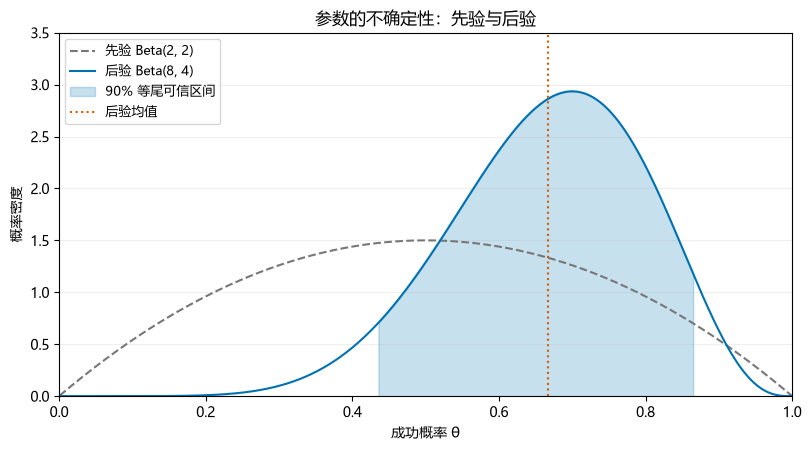

In [12]:
import matplotlib.pyplot as plt

plt.rcParams.update(
    {
        "font.sans-serif": ["Microsoft YaHei", "SimHei", "DejaVu Sans"],
        "axes.unicode_minus": False,
    }
)
# 先叠加先验与后验密度，阴影边界使用已计算的等尾分位数。
fig, ax = plt.subplots(figsize=(8, 4.4), layout="constrained")
ax.plot(theta_grid, prior_pdf, "--", color="#777777", label="先验 Beta(2, 2)")
ax.plot(theta_grid, posterior_pdf, color="#0072B2", label="后验 Beta(8, 4)")
interval_grid = np.linspace(credible[0], credible[1], 250)
# 只在可信区间内部填充后验曲线下方的面积。
ax.fill_between(
    interval_grid,
    beta.pdf(interval_grid, post_a, post_b),
    alpha=0.22,
    color="#0072B2",
    label="90% 等尾可信区间",
)
ax.axvline(posterior_mean, color="#D55E00", linestyle=":", label="后验均值")
ax.set(
    xlabel="成功概率 θ",
    ylabel="概率密度",
    xlim=(0, 1),
    ylim=(0, 3.5),
    title="参数的不确定性：先验与后验",
)
ax.legend(loc="upper left", fontsize=9)
ax.grid(axis="y", alpha=0.2)
plt.show()
# 阴影对应后验质量 0.9；端点由分位数确定，未按图片像素估计。

可信区间的概率条件是“已给定数据”。频率学派置信区间则考察固定参数、反复抽样时，由数据计算的随机区间覆盖参数的频率；观察后的某个置信区间不能自动获得相同数值的后验概率。

反过来，一个 90% 可信区间也不自动保证对每个固定参数都有 90% 的频率覆盖率。取 Beta(1,1) 先验、$n=4$，固定数据生成概率 $\theta_0=0.05$。枚举全部五种成功次数，精确计算等尾可信区间的覆盖率，不需要模拟。

In [13]:
small_n = 4
true_theta = 0.05
counts = np.arange(small_n + 1)
lower = beta.ppf(0.05, 1 + counts, 1 + small_n - counts)
upper = beta.ppf(0.95, 1 + counts, 1 + small_n - counts)
covered = (lower <= true_theta) & (true_theta <= upper)
sampling_probabilities = binom.pmf(counts, small_n, true_theta)
coverage = sampling_probabilities @ covered
print("包含 0.05 的成功次数：", counts[covered])  # 只有 0 次成功。
print("固定参数下的精确覆盖率：", coverage)  # 0.95**4 = 0.81450625，不是 0.9。
# 每个区间的后验质量仍为 0.9；两者对应不同的条件概率。

包含 0.05 的成功次数： [0]
固定参数下的精确覆盖率： 0.8145062500000003


## 8 后验预测面向新观测

未知参数与未来结果是不同对象。预测时既保留参数后验中的不确定性，也保留给定参数后观测本身的随机性。可以把预测理解为两步：先从参数后验取一个值，再按该参数的观测分布产生新结果。

![从参数后验抽出 θ，再在给定 θ 下抽出未来计数 K，重复两步形成后验预测。](image/illustration/27-01-posterior-prediction.svg)

图中 m 是未来试验次数，K 是其中成功次数，A、B 为正的 Beta 后验参数。它表示采样思路，不是实际样本；公式可以直接用积分完成同一加权过程。

若新结果 $X_{\mathrm{new}}$ 给定 $\theta$ 后与旧数据 D 条件独立，一次新观测的成功概率为

$$
P(X_{\mathrm{new}}=1\mid D)
=\int_0^1P(X_{\mathrm{new}}=1\mid\theta)\pi(\theta\mid D)\,d\theta
=\mathbb E[\theta\mid D].
$$

离散参数把积分换成加权求和。Beta(A,B) 模型给出 $A/(A+B)$，但这不表示参数已经确定为该值。下面先核对一次预测；随后计算多次试验的计数分布时，再沿图中的两层区分不确定性。

In [14]:
discrete_prediction = sum(t * p for t, p in zip(theta_small, posterior_small))
continuous_prediction, _ = quad(lambda t: t * beta.pdf(t, post_a, post_b), 0, 1)
print("第 1 节模型的下一次成功概率：", discrete_prediction)  # 5/8。
print("Beta(8, 4) 的下一次成功概率：", continuous_prediction)  # 2/3。
print("与后验均值的差值：", continuous_prediction - posterior_mean)  # 预期后验预测概率与后验均值相同；本次相减约为 -1.1e-16，是舍入量级。

第 1 节模型的下一次成功概率： 5/8
Beta(8, 4) 的下一次成功概率： 0.6666666666666665
与后验均值的差值： -1.1102230246251565e-16


若未来再进行 $m\geq1$ 次试验，令 $K_{\mathrm{new}}$ 表示成功次数，$j\in\{0,\ldots,m\}$。所有新试验共享同一个未知 $\theta$，给定它之后相互独立。将二项概率与 Beta 后验相乘并积分：

$$
\begin{aligned}
P(K_{\mathrm{new}}=j\mid D)
&=\int_0^1\binom mj\theta^j(1-\theta)^{m-j}
\frac{\theta^{A-1}(1-\theta)^{B-1}}{B(A,B)}\,d\theta\\
&=\binom mj\frac{B(A+j,B+m-j)}{B(A,B)}.
\end{aligned}
$$

这是 Beta–Binomial 分布，可用 scipy.stats.betabinom 计算。它通常不同于直接把后验均值代入二项分布，因为积分需要保留参数的不确定性。先用较小的 $m=10$ 核对公式、库结果和概率之和。

In [15]:
future_n = 10
future_counts = np.arange(future_n + 1)
predictive_formula = np.array(
    [
        comb(future_n, int(j))
        * beta_function(post_a + j, post_b + future_n - j)
        / beta_function(post_a, post_b)
        for j in future_counts
    ]
)
predictive_pmf = betabinom.pmf(future_counts, future_n, post_a, post_b)
plugin_pmf = binom.pmf(future_counts, future_n, posterior_mean)
print("预测概率之和：", predictive_pmf.sum())  # 应接近 1。
print("公式与库的最大差值：", np.max(np.abs(predictive_formula - predictive_pmf)))  # 本次数值约为 2.2e-16。
print("完整预测中至少 8 次成功的概率：", betabinom.sf(7, future_n, post_a, post_b))  # 预期约为 0.367315。
print("代入后验均值时的概率：", binom.sf(7, future_n, posterior_mean))  # 预期约为 0.299141。
# 至少 8 次要使用 P(K > 7)，而不是 P(K > 8)。

预测概率之和： 0.9999999999999994
公式与库的最大差值： 2.220446049250313e-16
完整预测中至少 8 次成功的概率： 0.3673153471915085
代入后验均值时的概率： 0.29914139104811255


## 9 区分两种不确定性

记 $\mu=\mathbb E[\theta\mid D]$、$v=\operatorname{Var}(\theta\mid D)$。在给定参数时，新计数的均值为 $m\theta$、方差为 $m\theta(1-\theta)$。利用“二阶矩 = 方差 + 均值平方”，先对参数平均：

$$
\mathbb E[K_{\mathrm{new}}^2\mid D]
=m\mathbb E[\theta\mid D]+(m^2-m)\mathbb E[\theta^2\mid D].
$$

减去预测均值 $(m\mu)$ 的平方，得到

$$
\operatorname{Var}(K_{\mathrm{new}}\mid D)
=\underbrace{m\mathbb E[\theta(1-\theta)\mid D]}_{\text{给定参数后仍存在的观测随机性}}
+\underbrace{m^2v}_{\text{参数不确定性}}
=m\mu(1-\mu)+m(m-1)v.
$$

这也解释了代入均值的二项分布为什么在 $m>1,v>0$ 时低估预测方差。对一次二元观测，$m=1$，完整预测恰好就是 Bernoulli($\mu$)，不能据此推断多次预测也等价。

In [16]:
observation_component = future_n * (posterior_mean - posterior_second_moment)
parameter_component = future_n**2 * posterior_variance
predictive_variance = observation_component + parameter_component
plugin_variance = future_n * posterior_mean * (1 - posterior_mean)

print("观测随机性部分：", observation_component)  # 预期约为 2.05128。
print("参数不确定性部分：", parameter_component)  # 预期约为 1.7094。
# 预期约为 3.76068 3.76068。
print(
    "完整预测方差与库结果：",
    predictive_variance,
    betabinom.var(future_n, post_a, post_b),
)
print("代入均值后的预测方差：", plugin_variance)  # 预期约为 2.22222。
# 预期约为 1.53846 1.53846。
print(
    "两者之差与推导值：",
    predictive_variance - plugin_variance,
    future_n * (future_n - 1) * posterior_variance,
)
# 完整预测方差约 3.761，代入均值约 2.222；单位均为次数的平方。

观测随机性部分： 2.0512820512820507
参数不确定性部分： 1.7094017094017095
完整预测方差与库结果： 3.76068376068376 3.760683760683761
代入均值后的预测方差： 2.2222222222222223
两者之差与推导值： 1.5384615384615379 1.5384615384615385


用两层模拟生成完整后验预测：每组先抽一个 $\theta^{(r)}\sim\operatorname{Beta}(A,B)$，再抽 $K^{(r)}\sim\operatorname{Binomial}(m,\theta^{(r)})$。这里 $r=1,\ldots,R$，取 $R=50000$ 个相互独立的模拟组。

每组的 $m$ 次试验共享该组的参数。不能在每个新试验前独立重抽参数，否则改变了联合预测模型。仅抽参数而不生成新计数，则只模拟了参数的不确定性。

对“至少 8 次成功”的模拟比例，理论概率记为 $q$，独立重复模拟的标准误为 $\sqrt{q(1-q)/R}$；它衡量计算误差，增加模拟次数并不会增加真实观测数据。

In [17]:
rng = np.random.default_rng(20260927)
repetitions = 50_000
parameter_draws = rng.beta(post_a, post_b, size=repetitions)
predictive_draws = rng.binomial(future_n, parameter_draws)
empirical_pmf = np.bincount(predictive_draws, minlength=future_n + 1) / repetitions
exact_event = betabinom.sf(7, future_n, post_a, post_b)
simulated_event = np.mean(predictive_draws >= 8)
monte_carlo_se = np.sqrt(exact_event * (1 - exact_event) / repetitions)

print("参数样本均值与理论值：", parameter_draws.mean(), posterior_mean)  # 本次固定种子参数样本均值约 0.666058；理论后验均值为 2/3，约 0.666667。
print("预测样本均值与理论值：", predictive_draws.mean(), future_n * posterior_mean)  # 本次固定种子预测样本均值为 6.65382；理论均值为 20/3，约 6.666667。
print("事件模拟比例与理论概率：", simulated_event, exact_event)  # 本次固定种子事件比例为 0.3656；理论事件概率约 0.367315。
print("模拟标准误：", monte_carlo_se)  # 本次固定种子下约为 0.0021559。
print("本次误差 / 标准误：", (simulated_event - exact_event) / monte_carlo_se)  # 本次固定种子下约为 -0.795653。
# 固定种子便于在本环境重现；有限次接近仅核对实现，不替代推导。

参数样本均值与理论值： 0.6660578671206699 0.6666666666666666
预测样本均值与理论值： 6.65382 6.666666666666666
事件模拟比例与理论概率： 0.3656 0.3673153471915085
模拟标准误： 0.002155897877493691
本次误差 / 标准误： -0.7956532679101955


下面将解析后验预测、两层模拟比例和代入均值的二项概率放在同一坐标上。横轴是新计数，不是参数 $\theta$；每一组柱或点的概率总和应为 1。

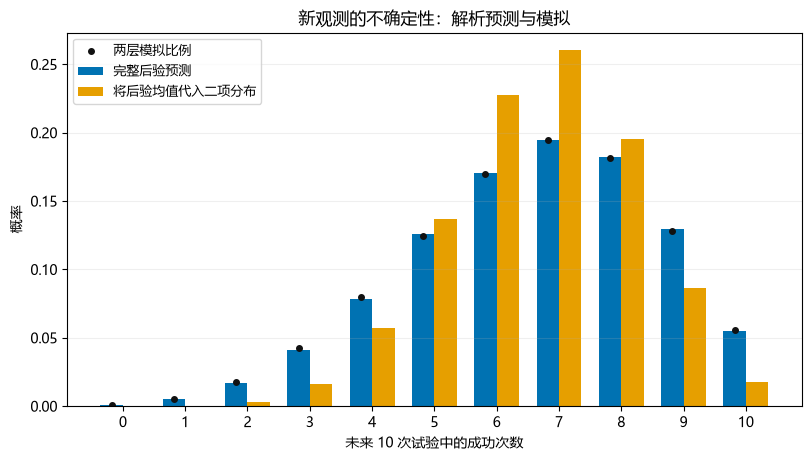

In [18]:
# 同一成功次数的两类柱左右错开，区分完整预测与代入均值的预测。
fig, ax = plt.subplots(figsize=(8, 4.5), layout="constrained")
ax.bar(
    future_counts - 0.18,
    predictive_pmf,
    width=0.36,
    color="#0072B2",
    label="完整后验预测",
)
ax.bar(
    future_counts + 0.18,
    plugin_pmf,
    width=0.36,
    color="#E69F00",
    label="将后验均值代入二项分布",
)
# 两层模拟频率对齐完整后验预测的蓝柱，作为解析结果的数值对照。
ax.plot(
    future_counts - 0.18,
    empirical_pmf,
    "o",
    color="#111111",
    markersize=4,
    label="两层模拟比例",
)
ax.set(
    xlabel="未来 10 次试验中的成功次数",
    ylabel="概率",
    xticks=future_counts,
    title="新观测的不确定性：解析预测与模拟",
)
ax.legend(fontsize=9, loc="upper left")
ax.grid(axis="y", alpha=0.2)
plt.show()
# 模拟点靠近蓝色柱；橙色柱对应另一种预测计算，不能与后验密度混读。

## 10 先验与数据量的影响

Beta 模型的后验均值可以写成

$$
\frac{a+k}{a+b+n}
=\frac{a+b}{a+b+n}\frac{a}{a+b}
+\frac{n}{a+b+n}\frac{k}{n}.
$$

它是先验均值与样本成功比例的加权平均。对固定的 $a,b>0$，随着 $n$ 增大，先验均值前的权重趋于 0；这是一条关于当前模型的代数结论，不是“任何先验都能被任意数据纠正”。

下面比较 Beta(1,1)、Beta(2,8)、Beta(8,2) 三种先验，分别使用人为设定的 $(n,k)=(8,6)$ 和 $(80,60)$。两组成功比例相同，目的是隔离数据量的影响；80 次记录表示新增试验，不能通过把 8 条记录复制十遍得到。

In [19]:
prior_options = [(1, 1), (2, 8), (8, 2)]
data_options = [(8, 6), (80, 60)]
for sample_n, success_k in data_options:
    print(f"n={sample_n}, k={success_k}")  # 分别打印 n=8, k=6 和 n=80, k=60，两批成功比例都为 0.75。
    for prior_a, prior_b in prior_options:
        updated_a = prior_a + success_k
        updated_b = prior_b + sample_n - success_k
        updated_mean = updated_a / (updated_a + updated_b)
        interval = beta.ppf([0.05, 0.95], updated_a, updated_b)
        forecast = betabinom.sf(7, 10, updated_a, updated_b)
        # 小样本三种后验均值约 0.7000、0.4444、0.7778；大样本约 0.7439、0.6889、0.7556，更集中于 0.75 附近。
        print(
            f"  Beta({prior_a}, {prior_b})：均值={updated_mean:.4f}，90%区间={np.round(interval, 4)}，未来至少8/10成功={forecast:.4f}"
        )
# 小样本时三种先验会给出明显不同的后验与预测；大样本时差异减小，但未必消失。

n=8, k=6
  Beta(1, 1)：均值=0.7000，90%区间=[0.4504 0.9023]，未来至少8/10成功=0.4443
  Beta(2, 8)：均值=0.4444，90%区间=[0.2601 0.636 ]，未来至少8/10成功=0.0578
  Beta(8, 2)：均值=0.7778，90%区间=[0.6044 0.9154]，未来至少8/10成功=0.6127
n=80, k=60
  Beta(1, 1)：均值=0.7439，90%区间=[0.6618 0.8192]，未来至少8/10成功=0.5126
  Beta(2, 8)：均值=0.6889，90%区间=[0.6067 0.7663]，未来至少8/10成功=0.3644
  Beta(8, 2)：均值=0.7556，90%区间=[0.6783 0.8263]，未来至少8/10成功=0.5456


两幅图使用相同横轴，分别显示两种数据量下的后验。颜色固定对应同一先验；纵轴高度随分布集中程度变化，不使用曲线峰高比较模型优劣。敏感性检查需要同时说明采用的先验和结果变化。

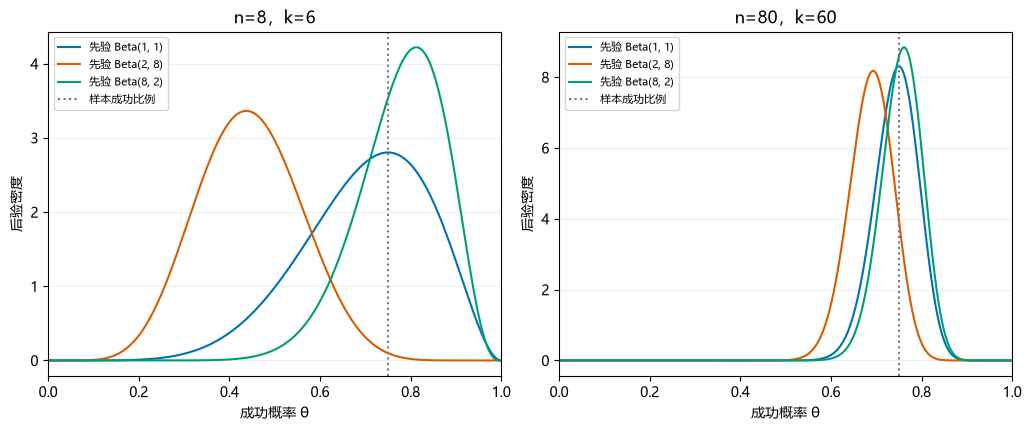

In [20]:
colors = ["#0072B2", "#D55E00", "#009E73"]
fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.2), layout="constrained", sharex=True)
# 外层选择数据量，内层改变先验；同一种先验在两图中保持相同颜色。
for ax, (sample_n, success_k) in zip(axes, data_options):
    for (prior_a, prior_b), color in zip(prior_options, colors):
        density = beta.pdf(
            theta_grid, prior_a + success_k, prior_b + sample_n - success_k
        )
        ax.plot(
            theta_grid, density, color=color, label=f"先验 Beta({prior_a}, {prior_b})"
        )
    # 竖线标记该数据集的样本成功比例，帮助观察先验引起的位置变化。
    ax.axvline(
        success_k / sample_n, color="#777777", linestyle=":", label="样本成功比例"
    )
    ax.set(
        xlabel="成功概率 θ",
        ylabel="后验密度",
        xlim=(0, 1),
        title=f"n={sample_n}，k={success_k}",
    )
    ax.legend(loc="upper left", fontsize=8)
    ax.grid(axis="y", alpha=0.2)
plt.show()
# 三种曲线的水平差异在右图更小；每条曲线的面积仍为 1。

## 11 综合应用：更新记录并预测下一批

用一个教学构造的发送试验串起全过程：把“收到确认”记为成功。假设装置状态不变，给定 $\theta$ 后各次试验独立。观察前设 Beta(2,2) 先验，两批新增记录分别为 8 次中成功 6 次、12 次中成功 9 次。

先核对顺序与整批更新，再报告 $\theta$ 的后验均值、90% 可信区间，以及下一批 10 次中至少成功 8 次的概率。参数超过 0.8，与下一批成功比例至少 0.8 是两个不同事件，要分别计算。

若设备状态变化或试验相关，同一固定概率的二项模型就不再直接适用；以上推断均以这个模型为条件。

In [21]:
batches = [(8, 6), (12, 9)]
sequence_a, sequence_b = 2.0, 2.0
for batch_n, batch_k in batches:
    sequence_a += batch_k
    sequence_b += batch_n - batch_k

all_n = sum(batch_n for batch_n, _ in batches)
all_k = sum(batch_k for _, batch_k in batches)
whole_a, whole_b = 2 + all_k, 2 + all_n - all_k
normalization, _ = quad(lambda t: beta.pdf(t, whole_a, whole_b), 0, 1)

print(
    "顺序与整批参数：", (sequence_a, sequence_b), (whole_a, whole_b)
)  # 都是 (17, 7)。
print("后验归一化误差：", abs(normalization - 1))  # 本例应小于 1e-12。
print("后验均值：", beta.mean(whole_a, whole_b))  # 预期约为 0.708333。
print("90% 可信区间：", beta.ppf([0.05, 0.95], whole_a, whole_b))  # 预期约为 [0.549025 0.84752]。
print("参数超过 0.8 的概率：", beta.sf(0.8, whole_a, whole_b))  # 预期约为 0.159833。
print("未来至少 8/10 次成功的概率：", betabinom.sf(7, 10, whole_a, whole_b))  # 预期约为 0.43437。
# 最后两行无需相等：一个是参数事件，一个是新观测事件。

顺序与整批参数： (17.0, 7.0) (17, 7)
后验归一化误差： 2.220446049250313e-16
后验均值： 0.7083333333333334
90% 可信区间： [0.5490246  0.84752031]
参数超过 0.8 的概率： 0.1598329530997329
未来至少 8/10 次成功的概率： 0.4343700978294971


## 本章小结

（1）后验由先验与似然的乘积归一化得到。离散参数用求和，连续参数用积分，证据必须为正。

（2）条件独立且没有重复的观测可以顺序更新。Beta 先验与二项似然共轭，成功数和失败数分别增加对应的形状参数。

（3）后验均值、MAP 和可信区间概括参数的不确定性。MAP 要检查边界，可信区间的后验概率与频率覆盖率有不同条件。

（4）后验预测对参数分布求平均，也保留新观测的随机性。先验敏感性、数据量和模型条件都影响结论。

理解自查：为什么密度大于 1 不矛盾？为什么复制记录不是新增信息？为什么下一次成功概率等于后验均值，却不能将未来整批计数直接当作固定参数二项分布？

## 练习

（1）将两个候选参数的先验改为 $(0.8,0.2)$，观察两次失败。手算后验并计算下一次成功概率。核对后验非负、和为 1，并解释下一次成功概率与 MAP 候选值的区别。

In [22]:
exercise_theta = np.array([0.25, 0.75])
exercise_prior = np.array([0.8, 0.2])
exercise_data = np.array([0, 0])
# 在此计算似然、后验及加权预测；先写手算结果，再运行核对。
print("候选参数与先验：", exercise_theta, exercise_prior)

候选参数与先验： [0.25 0.75] [0.8 0.2]


（2）使用 Beta(2,3) 先验，两批记录分别为 5 次中成功 3 次、4 次中成功 2 次。分别做顺序与整批更新，核对参数和密度一致。再故意将第一批重复输入一次，说明为什么得到的后验虽然能归一化，却不对应原始数据。

In [23]:
exercise_a, exercise_b = 2, 3
exercise_batches = [(5, 3), (4, 2)]
# 分别保存正确更新和重复记录后的参数，比较后验均值与方差。
print("先验参数和两批新增记录：", (exercise_a, exercise_b), exercise_batches)

先验参数和两批新增记录： (2, 3) [(5, 3), (4, 2)]


（3）对 Beta(3,7) 后验，求 90% 等尾可信区间并用 cdf 核对质量。有人据此说“未来 10 次试验的成功比例有 90% 概率落入该区间”，这句话是否成立？计算真正的后验预测质量：将所有满足 $l\leq j/10\leq u$ 的整数 $j$ 对应的概率相加。

In [24]:
exercise_post_a, exercise_post_b = 3, 7
exercise_future_n = 10
exercise_counts = np.arange(exercise_future_n + 1)
# 先求参数区间，再用整数计数筛选预测事件；不要对离散概率使用密度积分。
print("需要检查的未来成功比例：", exercise_counts / exercise_future_n)

需要检查的未来成功比例： [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]


（4）对同一 Beta(8,4) 后验，比较未来 $m=1$ 和 $m=12$ 次试验的完整预测与代入后验均值的预测。核对均值、概率之和与方差差值 $m(m-1)v$；解释什么条件下这两种预测一致。再说明逐次独立重抽参数为什么改变了“一批试验共享参数”的假设。

In [25]:
exercise_post_mean = 8 / 12
exercise_post_variance = 8 * 4 / (12**2 * 13)
exercise_sizes = [1, 12]
# 用 betabinom 和 binom 列出完整概率，核对方差差值；随后写出条件解释。
print(
    "后验均值、方差与预测批大小：",
    exercise_post_mean,
    exercise_post_variance,
    exercise_sizes,
)

后验均值、方差与预测批大小： 0.6666666666666666 0.017094017094017096 [1, 12]


## 练习提示与解析

以下对应练习（1）。先独立作答，卡住时依次查看提示，完成后再对照解析。

提示 1：先验乘两次失败的似然，得到尚未归一化的两个权重。

提示 2：下一次成功要按整个后验加权，而不是只使用权重最大的候选。

### 练习（1）参考解析

两个似然为 $(3/4)^2=9/16$ 与 $(1/4)^2=1/16$。乘先验后得到 $9/20$ 与 $1/80$，总和为 $37/80$，所以后验为 $(36/37,1/37)$。

下一次成功概率为 $\frac{36}{37}\frac14+\frac1{37}\frac34=39/148\approx0.26351$。MAP 候选为 1/4，它只取后验权重最大的参数；后验预测还保留另一候选的少量权重，所以两者不完全相同。

## 参考与引用来源

本章新增示意图由 CMYK Labs 原创，依据下表对应概念与本章教学输入绘制；示意图不作为实际运行截图或数学证明。

以下为写作前核查的官方或第一方资料；讲解与数值案例为本章重新组织的中文说明和原创教学例子。

| 网站 | 本章参考内容与定位 |
| --- | --- |
| MIT OpenCourseWare | 18.05（2022）：[Reading 11](https://ocw.mit.edu/courses/18-05-introduction-to-probability-and-statistics-spring-2022/mit18_05_s22_class11-prep.pdf) §3–4，第 2–7 页：先验、似然、归一化及顺序更新；[Reading 12a](https://ocw.mit.edu/courses/18-05-introduction-to-probability-and-statistics-spring-2022/mit18_05_s22_class12-prep-a.pdf) §3，第 2–3 页：离散后验预测；[Reading 13a](https://ocw.mit.edu/courses/18-05-introduction-to-probability-and-statistics-spring-2022/mit18_05_s22_class13-prep-a.pdf) §5、7–9，第 3–7 页：密度、连续归一化；[Reading 15](https://ocw.mit.edu/courses/18-05-introduction-to-probability-and-statistics-spring-2022/mit18_05_s22_class15-prep.pdf) §3–5.2，第 1–4 页：Beta 分布与二项共轭更新；[Reading 16a](https://ocw.mit.edu/courses/18-05-introduction-to-probability-and-statistics-spring-2022/mit18_05_s22_class16-prep-a.pdf) §2–3，第 1–3 页：先验影响及零先验边界；[Reading 16b](https://ocw.mit.edu/courses/18-05-introduction-to-probability-and-statistics-spring-2022/mit18_05_s22_class16-prep-b.pdf) §2，第 1–2 页：可信区间与分位数；[Reading 23a](https://ocw.mit.edu/courses/18-05-introduction-to-probability-and-statistics-spring-2022/mit18_05_s22_class23-prep-a.pdf) §5–7，第 8–10 页：置信区间与后验区间的解释差别。 |
| NIST Engineering Statistics Handbook | [Beta Distribution](https://www.itl.nist.gov/div898/handbook/eda/section3/eda366h.htm)，Probability Density Function、Common Statistics：Beta 函数积分、均值、方差及形状参数大于 1 时的众数。本章的共轭后验矩、内点 MAP 导数及边界例子据此展开。 |
| UBC STAT 405 | [Point estimates](https://ubc-stat-ml.github.io/web447/w02_discrete_bayes/topic04_point.html)，Definitions：后验均值与 MAP 的含义、点估计丢失不确定性信息。 |
| Stan User’s Guide | 2.40，[Posterior Predictive Sampling](https://mc-stan.org/docs/stan-users-guide/posterior-prediction.html)，Posterior predictive distribution、Sampling from the posterior predictive distribution：对参数积分、先抽参数再抽新数据，以及两类不确定性；本章仅借助其数学说明，不依赖 Stan。 |
| SciPy | 1.18 系列文档：[beta](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.beta.html) 的 Notes 与 pdf、cdf、sf、ppf、mean、var；[betabinom](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.betabinom.html) 的 Notes 与 pmf、sf、var；[binom](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.binom.html) 的 Notes 与 pmf、sf；[special.beta](https://docs.scipy.org/doc/scipy/reference/generated/scipy.special.beta.html) 的积分定义；[quad](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.quad.html) 的参数、返回值及误差估计。 |
| NumPy | 2.5 系列文档：[Generator](https://numpy.org/doc/stable/reference/random/generator.html) 的 default_rng、种子与版本兼容说明；[Generator.beta](https://numpy.org/doc/stable/reference/random/generated/numpy.random.Generator.beta.html)、[Generator.binomial](https://numpy.org/doc/stable/reference/random/generated/numpy.random.Generator.binomial.html) 的参数与抽样形状。 |
| Matplotlib | 3.11 系列 API：[Axes.plot](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.plot.html)、[Axes.bar](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.bar.html)、[Axes.fill_between](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.fill_between.html)：密度曲线、离散概率柱与区间阴影。 |